# Multiple Linear Regression — Property Price Prediction

**CN7030 – Machine Learning on Big Data**
Submitted  by: Mina Kumari Thapa 

This notebook builds several Linear Regression models on different combinations of property
features to predict `Price`, and compares them using R-squared (and supporting metrics MAE/RMSE).

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv("property__2_.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000000, 6)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Price
0,1360,2,3,1953,7860,3.039481e+05
1,4272,3,3,1997,5292,8.603863e+05
2,3592,4,1,1983,9723,7.343898e+05
3,966,6,1,1903,4086,2.264488e+05
4,4926,6,4,1944,1081,1.022486e+06


In [2]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Price
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,2750.657104,3.501114,2.500439,1960.527360,5502.373911,5.818397e+05
std,1298.569362,1.708174,1.117853,35.217804,2598.885883,2.606854e+05
min,500.000000,1.000000,1.000000,1900.000000,1000.000000,5.149571e+04
25%,1628.000000,2.000000,2.000000,1930.000000,3251.000000,3.571471e+05
50%,2749.000000,4.000000,3.000000,1960.000000,5501.000000,5.816477e+05
75%,3874.000000,5.000000,3.000000,1991.000000,7756.000000,8.066219e+05
max,4999.000000,6.000000,4.000000,2021.000000,9999.000000,1.123219e+06


## 2. Feature selection

Five candidate independent variables are available: `Square_Footage`, `Num_Bedrooms`,
`Num_Bathrooms`, `Year_Built`, `Lot_Size`. The dependent variable (target) is `Price`.

Before modelling, it's useful to check each feature's linear correlation with the target.

In [3]:
TARGET = "Price"
ALL_FEATURES = ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"]

df[ALL_FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)

Price             1.000000
Square_Footage    0.996345
Num_Bedrooms      0.033979
Num_Bathrooms     0.014161
Lot_Size          0.002952
Year_Built       -0.012853
Name: Price, dtype: float64

`Square_Footage` is very strongly correlated with `Price`; the other four features show
weak correlation individually. This motivates comparing models that include vs. exclude
`Square_Footage`, alongside other 4-feature subsets, to see how much each feature actually
contributes to predictive power.

## 3. Train/test split

A single 80/20 split is reused across all models so comparisons are fair (same train and test rows for every model).

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train size:", len(train_df), " Test size:", len(test_df))

Train size: 800000  Test size: 200000


## 4. Define feature-set combinations

One 5-feature model plus five 4-feature models, each dropping a different variable — this
lets us see the marginal contribution of each feature.

In [5]:
feature_sets = {
    "Model A: All 5 features": ALL_FEATURES,
    "Model B: Drop Year_Built": ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Lot_Size"],
    "Model C: Drop Lot_Size": ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Year_Built"],
    "Model D: Drop Num_Bathrooms": ["Square_Footage", "Num_Bedrooms", "Year_Built", "Lot_Size"],
    "Model E: Drop Num_Bedrooms": ["Square_Footage", "Num_Bathrooms", "Year_Built", "Lot_Size"],
    "Model F: Drop Square_Footage": ["Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"],
}
feature_sets

{'Model A: All 5 features': ['Square_Footage',
  'Num_Bedrooms',
  'Num_Bathrooms',
  'Year_Built',
  'Lot_Size'],
 'Model B: Drop Year_Built': ['Square_Footage',
  'Num_Bedrooms',
  'Num_Bathrooms',
  'Lot_Size'],
 'Model C: Drop Lot_Size': ['Square_Footage',
  'Num_Bedrooms',
  'Num_Bathrooms',
  'Year_Built'],
 'Model D: Drop Num_Bathrooms': ['Square_Footage',
  'Num_Bedrooms',
  'Year_Built',
  'Lot_Size'],
 'Model E: Drop Num_Bedrooms': ['Square_Footage',
  'Num_Bathrooms',
  'Year_Built',
  'Lot_Size'],
 'Model F: Drop Square_Footage': ['Num_Bedrooms',
  'Num_Bathrooms',
  'Year_Built',
  'Lot_Size']}

## 5. Train and evaluate each model

In [6]:
results = []
coef_records = {}

for name, feats in feature_sets.items():
    X_train, y_train = train_df[feats], train_df[TARGET]
    X_test, y_test = test_df[feats], test_df[TARGET]

    model = LinearRegression()
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append({
        "Model": name,
        "Features": ", ".join(feats),
        "Num_Features": len(feats),
        "R2": round(r2, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    })
    coef_records[name] = dict(zip(feats, model.coef_))

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,Features,Num_Features,R2,MAE,RMSE
0,Model A: All 5 features,"Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...",5,0.9941,15950.81,19987.96
1,Model C: Drop Lot_Size,"Square_Footage, Num_Bedrooms, Num_Bathrooms, Y...",4,0.9941,15953.00,19990.39
2,Model D: Drop Num_Bathrooms,"Square_Footage, Num_Bedrooms, Year_Built, Lot_...",4,0.9940,16165.40,20262.75
3,Model B: Drop Year_Built,"Square_Footage, Num_Bedrooms, Num_Bathrooms, L...",4,0.9939,16205.57,20303.99
4,Model E: Drop Num_Bedrooms,"Square_Footage, Num_Bathrooms, Year_Built, Lot...",4,0.9931,17378.41,21739.89
5,Model F: Drop Square_Footage,"Num_Bedrooms, Num_Bathrooms, Year_Built, Lot_Size",4,0.0015,225525.19,260640.60


## 6. Visual comparison of R-squared across models

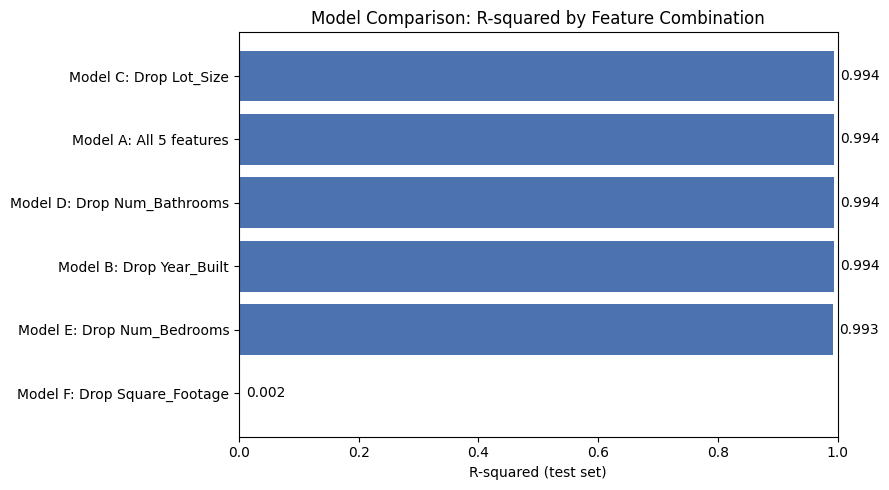

In [7]:
order = results_df.sort_values("R2")
plt.figure(figsize=(9, 5))
bars = plt.barh(order["Model"], order["R2"], color="#4C72B0")
plt.xlabel("R-squared (test set)")
plt.title("Model Comparison: R-squared by Feature Combination")
plt.xlim(0, 1)
for bar, val in zip(bars, order["R2"]):
    plt.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center")
plt.tight_layout()
plt.savefig("r2_comparison.png", dpi=150)
plt.show()

## 7. Coefficients of the best-performing model

In [8]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)
pd.Series(coef_records[best_model_name], name="Coefficient").sort_values(key=abs, ascending=False)

Best model: Model A: All 5 features


Num_Bedrooms      4978.224346
Num_Bathrooms     3031.264046
Square_Footage     200.009974
Year_Built         -99.730392
Lot_Size             0.100939
Name: Coefficient, dtype: float64

## 8. Summary of findings

- Any model **including `Square_Footage`** achieves R² ≈ 0.993–0.994, essentially explaining
  almost all of the variance in `Price`.
- The single model that **excludes `Square_Footage`** (Model F) collapses to R² ≈ 0.002 — i.e.
  almost no predictive power — confirming that `Square_Footage` is overwhelmingly the dominant
  driver of price in this dataset.
- `Num_Bedrooms`, `Num_Bathrooms`, `Year_Built`, and `Lot_Size` each add only a marginal
  improvement on top of `Square_Footage`, consistent with their weak individual correlations
  with `Price`.
- The full reflective write-up discussing these results is provided separately as a one-page
  summary document.

---

# Reflective Summary

**CN7030 – Machine Learning on Big Data | Mina Kumari Thapa**

## Feature Selection

The property dataset (1,000,000 records) offers five candidate independent variables: `Square_Footage`, `Num_Bedrooms`, `Num_Bathrooms`, `Year_Built`, and `Lot_Size`, with `Price` as the dependent variable. Rather than picking a single fixed set of 4–5 features, I evaluated six combinations: the full 5-feature model, and five 4-feature models each omitting exactly one variable. This leave-one-out design isolates the marginal contribution of each feature rather than only reporting one arbitrary subset, and was informed by an initial correlation check against `Price`, which immediately flagged `Square_Footage` as the dominant signal (r ≈ 0.996) against near-zero correlations for the remaining four features.

## Model Comparison — Observations

All six models were trained with scikit-learn's `LinearRegression` on an identical 80/20 train-test split (`random_state=42`) to keep the comparison fair.

- Every model that **includes** `Square_Footage` achieves R² between 0.993 and 0.994 — essentially all of the explainable variance in `Price`.
- The single model that **excludes** `Square_Footage` (Model F) collapses to R² ≈ 0.002 — almost no predictive power — confirming that `Square_Footage` is overwhelmingly the dominant driver of price in this dataset.
- Among the models that do include `Square_Footage`, dropping `Lot_Size` or `Year_Built` barely moves R² at all, showing those two features add little on top of what `Square_Footage` already captures.
- `Num_Bedrooms` and `Num_Bathrooms` contribute slightly more than `Lot_Size`/`Year_Built`, but still marginally compared to `Square_Footage`.

## Challenges Faced and How I Resolved Them

The main challenge was scale: at one million rows, some exploratory approaches (e.g. pairwise scatterplots across all features) became slow and cluttered, so I used a correlation matrix first to prioritise which relationships were worth visualising in more depth. A second challenge was interpreting the near-zero R² for Model F — initially this looked like a possible bug, but re-checking the correlation table confirmed it was an expected and informative result, not an error, once `Square_Footage` was removed. Reusing a single train/test split across all six models also avoided the subtle pitfall of each model being evaluated on slightly different data, which would have made the R² comparison unfair.

## Insights Gained

This exercise reinforced that R² comparisons are only meaningful when the evaluation setup is held constant across models, and that a quick correlation check before modelling can predict which features will matter most. It also showed a limitation of R² alone: a near-perfect R² does not by itself validate a model, since in this dataset it is really `Square_Footage` doing almost all of the work — a useful reminder to inspect individual feature coefficients and correlations, not just the aggregate R², before drawing conclusions about which variables genuinely drive the outcome.
